<a href="https://colab.research.google.com/github/ojasvi-1705/Applied-Machine-Learning/blob/main/K_meanClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#1) Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [16]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [17]:
# 2) Import dataset
df = pd.read_csv("Mall_Customers.csv")

In [18]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [19]:
# 3) Drop CustomerID column
df = df.drop("CustomerID", axis=1)


In [20]:
# 4) Encode Gender column
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
# Female = 0, Male = 1
print(df.head())




   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


In [21]:
# 5) Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

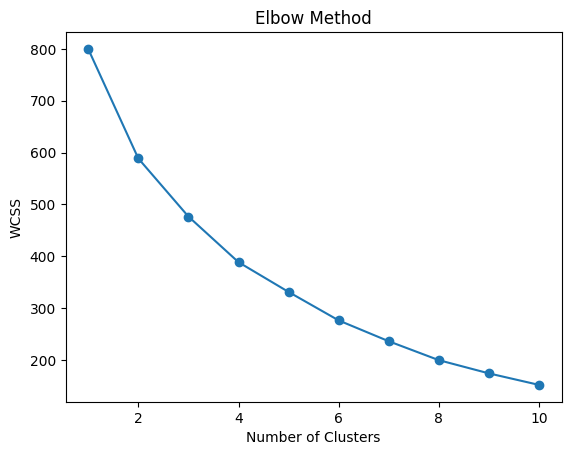

In [22]:
# 6) Elbow Method to find best K
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [23]:
# 7) Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   19                  15                      39        3
1       1   21                  15                      81        3
2       0   20                  16                       6        3
3       0   23                  16                      77        3
4       0   31                  17                      40        3


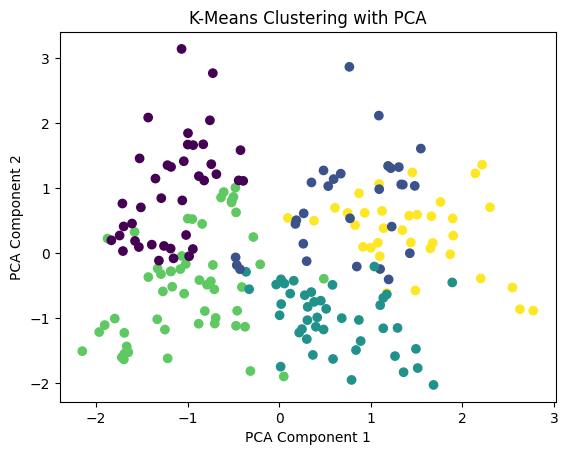

In [24]:
# 8) PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clustering with PCA")
plt.show()